In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [3]:
import os
import requests
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torchaudio
import torch
from pathlib import Path
from collections import Counter

DATA_DIR = Path("data/audio/ESC-50")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchaudio: {torchaudio.__version__}")
print(f"Librosa: {librosa.__version__}")

Data directory: C:\Users\vinay\OneDrive\Desktop\VATSA\VATSA\notebooks\data\audio\ESC-50
PyTorch: 2.6.0+cu124
Torchaudio: 2.6.0+cu124
Librosa: 0.11.0


In [4]:
ESC50_URL = "https://github.com/karoldvl/ESC-50/archive/master.zip"
ZIP_PATH = DATA_DIR / "ESC-50-master.zip"
EXTRACT_PATH = DATA_DIR

if not (DATA_DIR / "ESC-50-master").exists():
    print("Downloading ESC-50...")
    response = requests.get(ESC50_URL, stream=True)
    with open(ZIP_PATH, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Download complete. Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_PATH)
    os.remove(ZIP_PATH)
    print("Done.")
else:
    print("ESC-50 already exists, skipping download.")

ESC50_DIR = DATA_DIR / "ESC-50-master"
AUDIO_DIR = ESC50_DIR / "audio"
META_PATH = ESC50_DIR / "meta" / "esc50.csv"

ESC-50 already exists, skipping download.


In [5]:
df = pd.read_csv(META_PATH)
print(f"Total samples: {len(df)}")
print(f"Total classes: {df['category'].nunique()}")
print(f"Samples per class: {df.groupby('category').size().unique()} (should be uniform)")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample rows:")
df.head()

Total samples: 2000
Total classes: 50
Samples per class: [40] (should be uniform)

Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']

Sample rows:


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


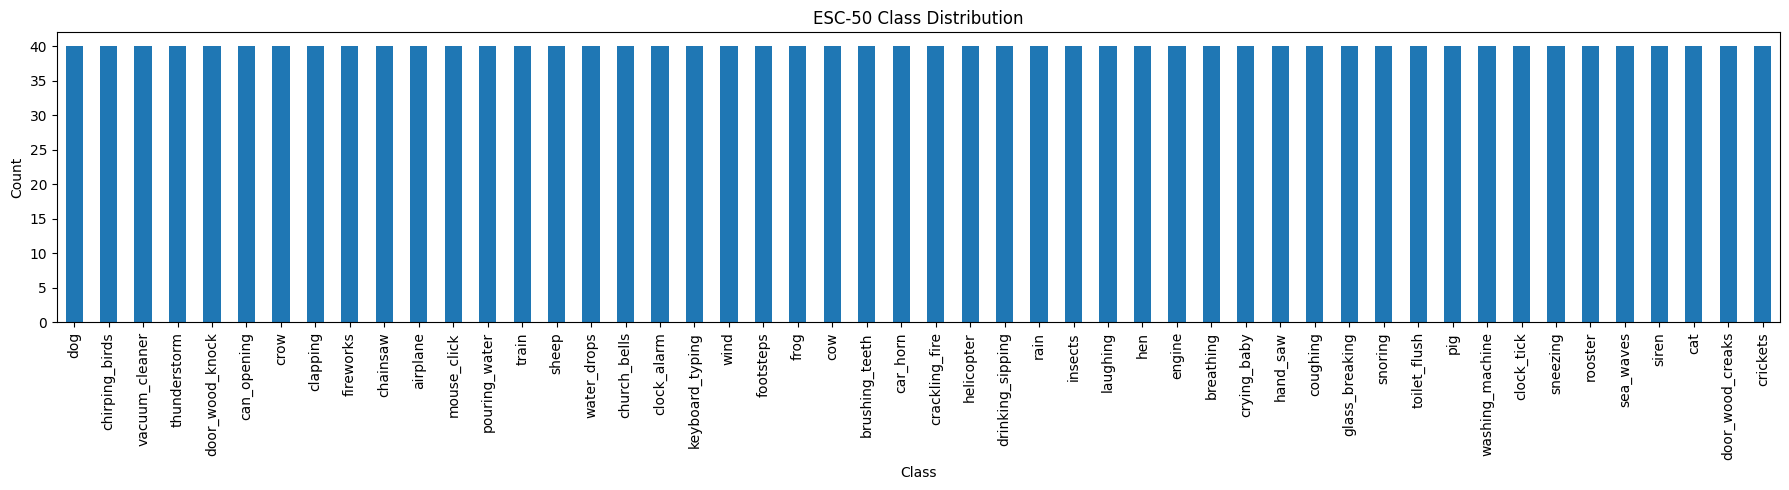


All 50 classes:
['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']


In [6]:
class_counts = df['category'].value_counts()
plt.figure(figsize=(18, 5))
class_counts.plot(kind='bar')
plt.title("ESC-50 Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
print(f"\nAll 50 classes:\n{sorted(df['category'].unique())}")

In [7]:
# CIFAR-10 classes we need to map to
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# ESC-50 classes mapped to CIFAR-10
# None = not available in ESC-50, needs synthesis
ESC50_TO_CIFAR10 = {
    'airplane'   : ['airplane', 'helicopter'],   # both aerial vehicles
    'automobile' : ['car_horn'],                  # weak match - noted
    'bird'       : ['chirping_birds'],            # one class to fix imbalance
    'cat'        : ['cat'],
    'deer'       : None,                          # needs synthesis
    'dog'        : ['dog'],
    'frog'       : ['frog'],
    'horse'      : ['cow', 'pig', 'sheep'],       # farm animals - weak but present
    'ship'       : ['sea_waves', 'engine'],       # combined - better for ship
    'truck'      : ['train'],                     # heavy vehicle - reasonable match
}
print("CIFAR-10 → ESC-50 Mapping:")
print("-" * 45)
for cifar_class, esc_classes in ESC50_TO_CIFAR10.items():
    status = "✅" if esc_classes else "❌ NEEDS SYNTHESIS"
    mapped = ", ".join(esc_classes) if esc_classes else "—"
    print(f"{cifar_class:<15} → {mapped:<30} {status}")

# Check all mapped ESC-50 classes actually exist in dataset
all_esc50_classes = set(df['category'].unique())
print("\nValidating mapping against actual ESC-50 classes...")
for cifar_class, esc_classes in ESC50_TO_CIFAR10.items():
    if esc_classes:
        for ec in esc_classes:
            if ec not in all_esc50_classes:
                print(f"  ⚠️  '{ec}' not found in ESC-50 for CIFAR class '{cifar_class}'")
print("Validation done.")

CIFAR-10 → ESC-50 Mapping:
---------------------------------------------
airplane        → airplane, helicopter           ✅
automobile      → car_horn                       ✅
bird            → chirping_birds                 ✅
cat             → cat                            ✅
deer            → —                              ❌ NEEDS SYNTHESIS
dog             → dog                            ✅
frog            → frog                           ✅
horse           → cow, pig, sheep                ✅
ship            → sea_waves, engine              ✅
truck           → train                          ✅

Validating mapping against actual ESC-50 classes...
Validation done.


In [8]:
CIFAR10_LABEL_MAP = {c: i for i, c in enumerate(CIFAR10_CLASSES)}
SAMPLES_PER_CLASS = 40  # cap for balanced baseline

rows = []
for cifar_class, esc_classes in ESC50_TO_CIFAR10.items():
    if esc_classes:
        subset = df[df['category'].isin(esc_classes)].copy()
        subset['cifar_class'] = cifar_class
        subset['cifar_label'] = CIFAR10_LABEL_MAP[cifar_class]
        # cap at 40
        subset = subset.sample(n=min(SAMPLES_PER_CLASS, len(subset)), 
                               random_state=42)
        rows.append(subset)

mapped_df = pd.concat(rows, ignore_index=True)
print(f"Total mapped samples (before deer synthesis): {len(mapped_df)}")
print(f"\nSamples per CIFAR-10 class:")
print(mapped_df.groupby('cifar_class')['filename'].count())
print(f"\nMissing: deer only — to be added via synthesis")

Total mapped samples (before deer synthesis): 360

Samples per CIFAR-10 class:
cifar_class
airplane      40
automobile    40
bird          40
cat           40
dog           40
frog          40
horse         40
ship          40
truck         40
Name: filename, dtype: int64

Missing: deer only — to be added via synthesis


In [9]:
# Check exact names for horse and engine related classes
all_classes = sorted(df['category'].unique())
for c in all_classes:
    if any(word in c for word in ['horse', 'engine', 'motor', 'car', 'vehicle', 'truck', 'ship', 'boat']):
        print(c)

car_horn
engine


In [10]:
durations = []
sample_rates = []

for fname in mapped_df['filename'].values[:50]:  # sample 50 for speed
    path = AUDIO_DIR / fname
    y, sr = librosa.load(path, sr=None)
    durations.append(len(y) / sr)
    sample_rates.append(sr)

print(f"Sample rate (all files): {set(sample_rates)}")
print(f"Duration - Min: {min(durations):.2f}s  Max: {max(durations):.2f}s  Mean: {np.mean(durations):.2f}s")

c:\Users\vinay\OneDrive\Desktop\VATSA\VATSA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample rate (all files): {44100}
Duration - Min: 5.00s  Max: 5.00s  Mean: 5.00s


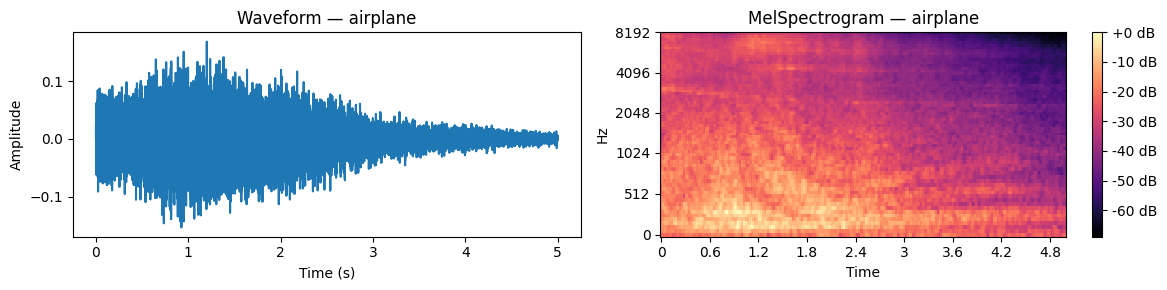

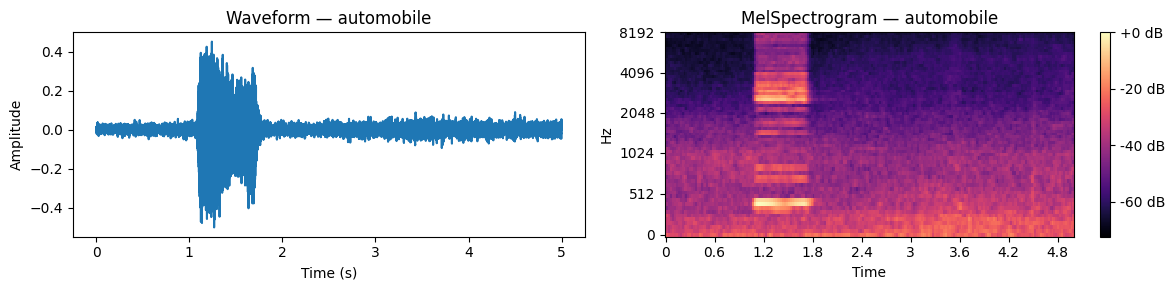

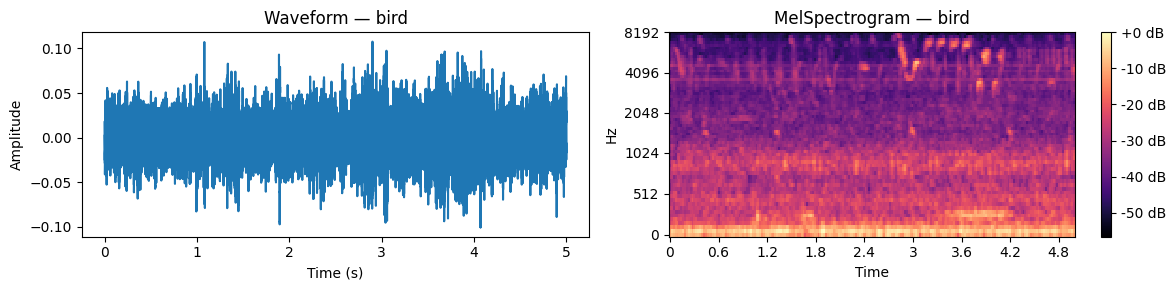

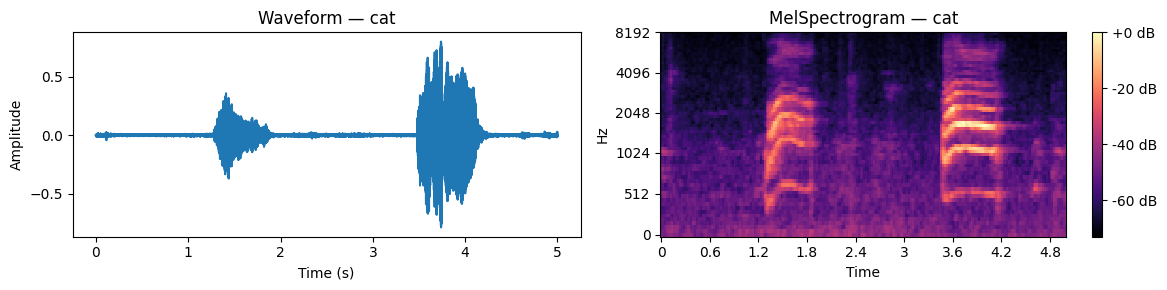

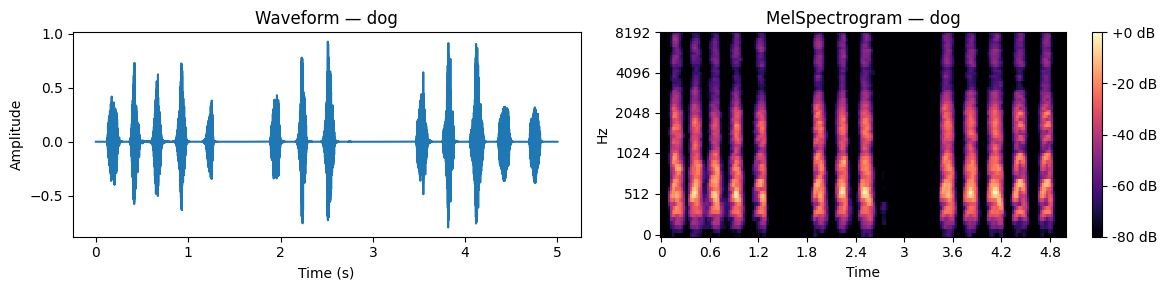

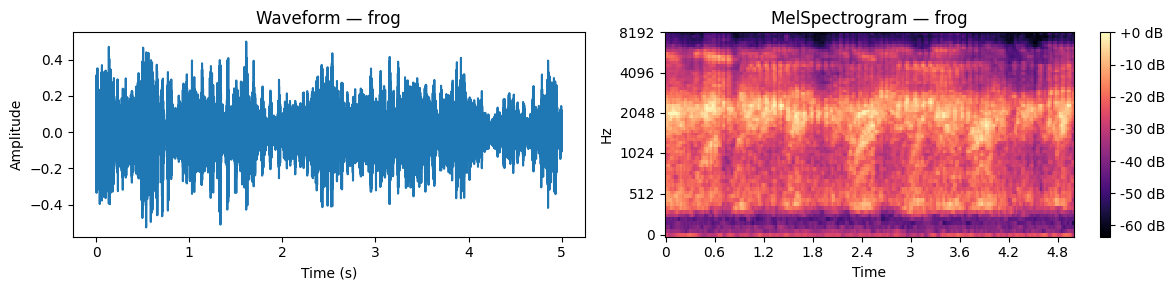

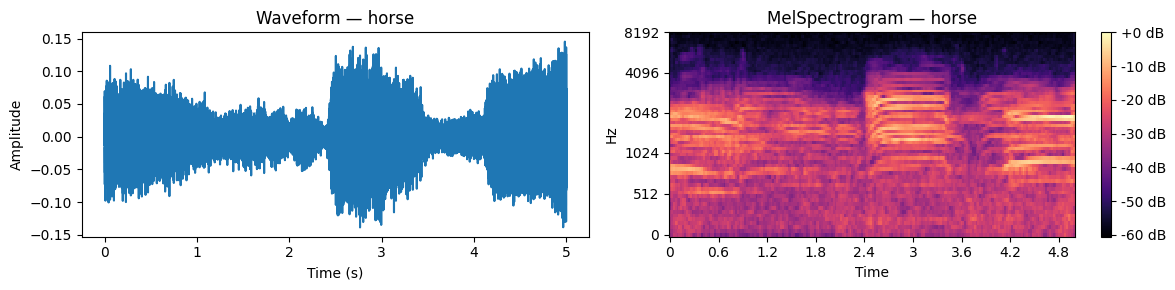

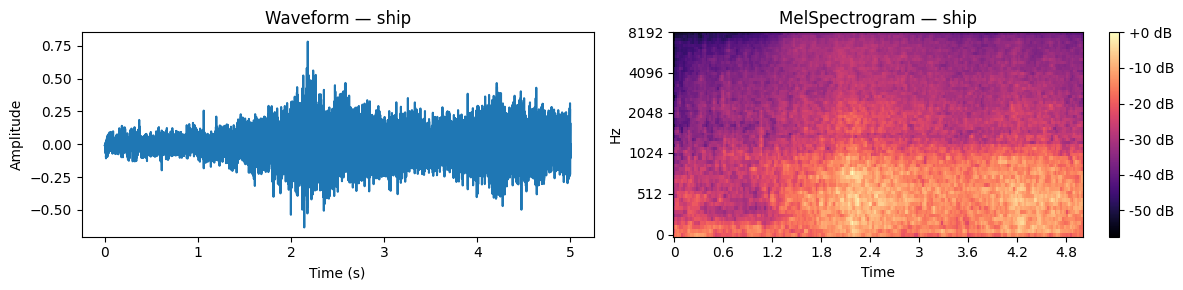

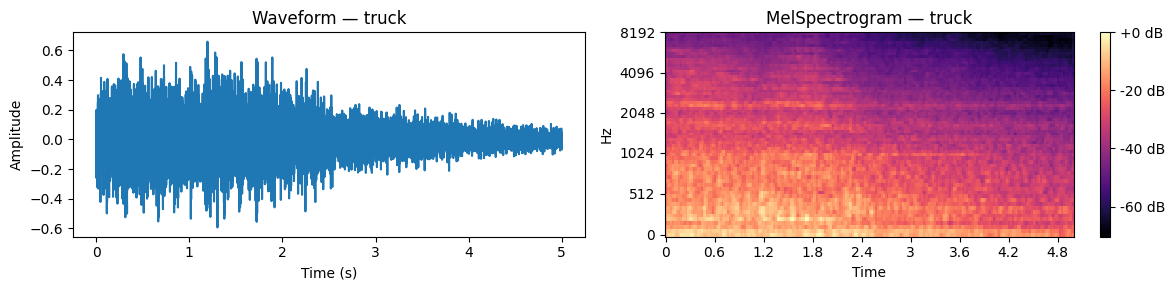

In [11]:
def plot_sample(filepath, title=""):
    y, sr = librosa.load(filepath, sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    # Waveform
    axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y)
    axes[0].set_title(f"Waveform — {title}")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")

    # MelSpectrogram
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], fmax=8000)
    axes[1].set_title(f"MelSpectrogram — {title}")
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

# Plot one sample per available CIFAR-10 class
for cifar_class, esc_classes in ESC50_TO_CIFAR10.items():
    if esc_classes:
        sample = mapped_df[mapped_df['cifar_class'] == cifar_class].iloc[0]
        plot_sample(AUDIO_DIR / sample['filename'], title=cifar_class)

In [12]:
import torch
import numpy as np
import soundfile as sf
from transformers import pipeline
DATA_DIR = Path("data/audio/ESC-50")
DEER_DIR = DATA_DIR / "synthesised" / "deer"
DEER_DIR.mkdir(parents=True, exist_ok=True)

# Load AudioGen via HuggingFace pipeline
print("Loading musicgen-small model (first run will download)...")
synthesiser = pipeline(
    "text-to-audio",
    model="facebook/musicgen-small",  # smaller, better supported
    device=0 if torch.cuda.is_available() else -1
)
print("Model loaded.")

# Varied prompts for diversity across 40 samples
prompts = [
    "deer walking through forest",
    "deer running through woods",
    "deer hooves on dry leaves",
    "deer moving through undergrowth",
    "deer galloping in open field",
    "deer stepping on twigs in forest",
    "deer hooves crunching on grass",
    "deer running fast through trees",
] * 5  # 8 x 5 = 40

prompts = prompts[:40]

print(f"\nGenerating {len(prompts)} deer audio samples...")
for i, prompt in enumerate(prompts):
    output = synthesiser(
        prompt,
        forward_params={"max_new_tokens": 512}  # ~5 seconds
    )
    
    audio = output["audio"].squeeze()  # flatten to 1D
    sr = output["sampling_rate"]
    
    # Pad or trim to exactly 5 seconds to match ESC-50
    target_samples = sr * 5
    if len(audio) < target_samples:
        audio = np.pad(audio, (0, target_samples - len(audio)))
    else:
        audio = audio[:target_samples]
    
    filepath = DEER_DIR / f"deer_synth_{i:03d}.wav"
    sf.write(str(filepath), audio, sr)
    
    if (i + 1) % 5 == 0:
        print(f"  Generated {i+1}/40")

print(f"\n✅ Deer synthesis complete")
print(f"Saved to: {DEER_DIR}")
print(f"Files generated: {len(list(DEER_DIR.glob('*.wav')))}")

Loading musicgen-small model (first run will download)...


Loading weights: 100%|██████████| 611/611 [00:00<00:00, 3113.41it/s]
[transformers] MusicgenForConditionalGeneration LOAD REPORT from: facebook/musicgen-small
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decoder.model.decoder.embed_positions.weights | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Model loaded.

Generating 40 deer audio samples...
  Generated 5/40


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Generated 10/40
  Generated 15/40
  Generated 20/40
  Generated 25/40
  Generated 30/40
  Generated 35/40
  Generated 40/40

✅ Deer synthesis complete
Saved to: data\audio\ESC-50\synthesised\deer
Files generated: 40


In [13]:
print(f"Files generated: {len(list(DEER_DIR.glob('*.wav')))}")

Files generated: 40


In [14]:
# Add synthesised deer samples to mapped_df
deer_files = sorted(DEER_DIR.glob("*.wav"))

deer_rows = []
for i, filepath in enumerate(deer_files):
    deer_rows.append({
        'filename'   : str(filepath.resolve()),
        'category'   : 'deer_synth',
        'cifar_class': 'deer',
        'cifar_label': CIFAR10_LABEL_MAP['deer'],
        'synthesised': True
    })

deer_df = pd.DataFrame(deer_rows)

# Mark original mapped_df samples as not synthesised
mapped_df['synthesised'] = False
# filename in mapped_df is just the filename not full path
# store full path for consistency
mapped_df['full_path'] = mapped_df['filename'].apply(lambda x: str((AUDIO_DIR / x).resolve()))

# Add full_path to deer_df too
deer_df['full_path'] = deer_df['filename']

# Combine
full_df = pd.concat([mapped_df, deer_df], ignore_index=True)

print(f"Total samples: {len(full_df)}")
print(f"\nSamples per CIFAR-10 class:")
print(full_df.groupby('cifar_class')['cifar_label'].count().sort_index())
print(f"\nSynthesised samples: {full_df['synthesised'].sum()}")
print(f"Real samples: {(~full_df['synthesised']).sum()}")

Total samples: 400

Samples per CIFAR-10 class:
cifar_class
airplane      40
automobile    40
bird          40
cat           40
deer          40
dog           40
frog          40
horse         40
ship          40
truck         40
Name: cifar_label, dtype: int64

Synthesised samples: 40
Real samples: 360


In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

class ESC50Dataset(Dataset):
    def __init__(self, dataframe, audio_dir, sample_rate=22050, duration=5, n_mels=64, target_col='cifar_label'):
        self.df = dataframe.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.sample_rate = sample_rate
        self.n_samples = sample_rate * duration
        self.n_mels = n_mels
        self.target_col = target_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.audio_dir / row['filename']

        y, sr = librosa.load(path, sr=self.sample_rate, duration=5.0)

        # Pad or trim to fixed length
        if len(y) < self.n_samples:
            y = np.pad(y, (0, self.n_samples - len(y)))
        else:
            y = y[:self.n_samples]

        # MelSpectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=self.sample_rate, n_mels=self.n_mels, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalise to [-1, 1]
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)

        # Shape: (1, n_mels, time_steps) — channel first for CNN or (time_steps, n_mels) for RNN
        mel_tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)

        label = torch.tensor(row[self.target_col], dtype=torch.long)
        return mel_tensor, label

Playing: deer_synth_000.wav


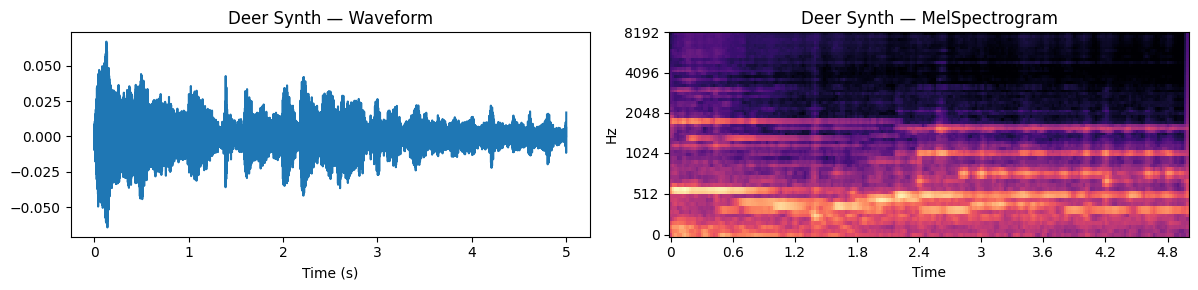

In [16]:
import IPython.display as ipd

# Quick sanity check - listen to one synthesised deer sample
sample_path = str(deer_files[0])
y, sr = librosa.load(sample_path, sr=22050)
print(f"Playing: {deer_files[0].name}")
ipd.display(ipd.Audio(y, rate=sr))

# Also visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=8000)
mel_db = librosa.power_to_db(mel, ref=np.max)

axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y)
axes[0].set_title("Deer Synth — Waveform")
axes[0].set_xlabel("Time (s)")

librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], fmax=8000)
axes[1].set_title("Deer Synth — MelSpectrogram")
plt.tight_layout()
plt.show()

In [17]:
from torch.utils.data import Dataset, DataLoader

class ESC50Dataset(Dataset):
    def __init__(self, dataframe, sample_rate=22050, duration=5, n_mels=64):
        self.df         = dataframe.reset_index(drop=True)
        self.sample_rate = sample_rate
        self.n_samples  = sample_rate * duration
        self.n_mels     = n_mels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = row['full_path']

        y, sr = librosa.load(path, sr=self.sample_rate, duration=5.0)

        # Pad or trim to fixed length
        if len(y) < self.n_samples:
            y = np.pad(y, (0, self.n_samples - len(y)))
        else:
            y = y[:self.n_samples]

        # MelSpectrogram
        mel    = librosa.feature.melspectrogram(y=y, sr=self.sample_rate, 
                                                 n_mels=self.n_mels, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalise
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)

        # Shape: (time_steps, n_mels) — RNN expects sequence first
        mel_tensor = torch.tensor(mel_db.T, dtype=torch.float32)

        label = torch.tensor(row['cifar_label'], dtype=torch.long)
        return mel_tensor, label

In [18]:
import torch.nn as nn

class VATSA_AudioEncoder(nn.Module):
    def __init__(self, input_size=64, hidden_size=128, num_layers=1, 
                 num_classes=10, embedding_dim=512, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size  = input_size,   # n_mels
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        
        self.dropout    = nn.Dropout(dropout)
        self.projection = nn.Linear(hidden_size, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, n_mels)
        lstm_out, (hidden, _) = self.lstm(x)
        
        # Take last hidden state
        last_hidden = hidden[-1]                    # (batch, hidden_size)
        last_hidden = self.dropout(last_hidden)
        
        embedding = self.projection(last_hidden)    # (batch, embedding_dim)
        logits    = self.classifier(embedding)      # (batch, num_classes)
        
        return logits, embedding


# Quick architecture check
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = VATSA_AudioEncoder(
    input_size   = 64,
    hidden_size  = 128,
    num_layers   = 1,
    num_classes  = 10,
    embedding_dim= 512,
    dropout      = 0.3
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Device: cuda
Total parameters: 170,506

Model architecture:
VATSA_AudioEncoder(
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (projection): Linear(in_features=128, out_features=512, bias=True)
  (classifier): Linear(in_features=512, out_features=10, bias=True)
)


In [19]:
from sklearn.model_selection import StratifiedKFold
import torch.optim as optim
import copy

EPOCHS      = 30
BATCH_SIZE  = 16
LR          = 1e-3
N_FOLDS     = 5
HIDDEN_SIZE = 128
EMBED_DIM   = 512

skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
labels  = full_df['cifar_label'].values

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(full_df, labels)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*50}")
    
    train_df = full_df.iloc[train_idx]
    val_df   = full_df.iloc[val_idx]
    
    train_dataset = ESC50Dataset(train_df)
    val_dataset   = ESC50Dataset(val_df)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, 
                              shuffle=False, num_workers=0)
    
    model = VATSA_AudioEncoder(
        input_size    = 64,
        hidden_size   = HIDDEN_SIZE,
        num_layers    = 1,
        num_classes   = 10,
        embedding_dim = EMBED_DIM,
        dropout       = 0.3
    ).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    best_val_acc  = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(EPOCHS):
        # Train
        model.train()
        running_loss = 0.0
        for mel, label in train_loader:
            mel, label = mel.to(device), label.to(device)
            optimizer.zero_grad()
            logits, _ = model(mel)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        scheduler.step()
        avg_loss = running_loss / len(train_loader)
        
        # Validate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for mel, label in val_loader:
                mel, label = mel.to(device), label.to(device)
                logits, _ = model(mel)
                correct += (logits.argmax(1) == label).sum().item()
                total   += label.size(0)
        
        val_acc = correct / total * 100
        
        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} - Val Acc: {val_acc:.2f}%")
    
    print(f"  Best Val Acc — Fold {fold+1}: {best_val_acc:.2f}%")
    fold_results.append(best_val_acc)

print(f"\n{'='*50}")
print(f"K-FOLD RESULTS SUMMARY")
print(f"{'='*50}")
for i, acc in enumerate(fold_results):
    print(f"  Fold {i+1}: {acc:.2f}%")
print(f"\n  Mean Accuracy: {np.mean(fold_results):.2f}%")
print(f"  Std Deviation: {np.std(fold_results):.2f}%")


FOLD 1/5
  Epoch 10/30 - Loss: 0.9819 - Val Acc: 48.75%
  Epoch 20/30 - Loss: 0.3894 - Val Acc: 55.00%
  Epoch 30/30 - Loss: 0.2730 - Val Acc: 56.25%
  Best Val Acc — Fold 1: 57.50%

FOLD 2/5
  Epoch 10/30 - Loss: 1.1198 - Val Acc: 47.50%
  Epoch 20/30 - Loss: 0.5487 - Val Acc: 50.00%
  Epoch 30/30 - Loss: 0.3383 - Val Acc: 55.00%
  Best Val Acc — Fold 2: 56.25%

FOLD 3/5
  Epoch 10/30 - Loss: 0.9846 - Val Acc: 35.00%
  Epoch 20/30 - Loss: 0.3844 - Val Acc: 48.75%
  Epoch 30/30 - Loss: 0.2732 - Val Acc: 51.25%
  Best Val Acc — Fold 3: 56.25%

FOLD 4/5
  Epoch 10/30 - Loss: 1.1838 - Val Acc: 36.25%
  Epoch 20/30 - Loss: 0.4224 - Val Acc: 47.50%
  Epoch 30/30 - Loss: 0.2993 - Val Acc: 46.25%
  Best Val Acc — Fold 4: 51.25%

FOLD 5/5
  Epoch 10/30 - Loss: 0.9006 - Val Acc: 33.75%
  Epoch 20/30 - Loss: 0.4688 - Val Acc: 45.00%
  Epoch 30/30 - Loss: 0.2823 - Val Acc: 43.75%
  Best Val Acc — Fold 5: 46.25%

K-FOLD RESULTS SUMMARY
  Fold 1: 57.50%
  Fold 2: 56.25%
  Fold 3: 56.25%
  Fold 4: 

In [20]:
CIFAR10_CLASSES_LIST = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Retrain on full data for final per-class evaluation
# (for research purposes — real deployment would use held-out test set)
full_dataset = ESC50Dataset(full_df)
full_loader  = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Load best fold model
model.load_state_dict(best_model_wts)
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for mel, label in full_loader:
        mel, label = mel.to(device), label.to(device)
        logits, _  = model(mel)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(label.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
overall_acc = (all_preds == all_labels).mean() * 100
print(f"Overall Accuracy: {overall_acc:.2f}%")
print(f"\nPer-Class Accuracy:")
print(f"{'Class':<15} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 45)

for i, cls in enumerate(CIFAR10_CLASSES_LIST):
    mask    = all_labels == i
    correct = (all_preds[mask] == all_labels[mask]).sum()
    total   = mask.sum()
    acc     = correct / total * 100 if total > 0 else 0
    flag    = " ⚠️" if acc < 50 else ""
    print(f"{cls:<15} {correct:>8} {total:>8} {acc:>9.2f}%{flag}")

Overall Accuracy: 82.25%

Per-Class Accuracy:
Class            Correct    Total   Accuracy
---------------------------------------------
airplane              36       40     90.00%
automobile            33       40     82.50%
bird                  34       40     85.00%
cat                   27       40     67.50%
deer                  36       40     90.00%
dog                   29       40     72.50%
frog                  38       40     95.00%
horse                 30       40     75.00%
ship                  31       40     77.50%
truck                 35       40     87.50%


In [21]:
# Save best model
torch.save({
    'model_state' : best_model_wts,
    'embedding_dim': EMBED_DIM,
    'hidden_size' : HIDDEN_SIZE,
    'input_size'  : 64,
    'num_classes' : 10,
    'fold_results': fold_results,
}, "vatsa_audio_encoder_baseline.pth")

print("✅ VATSA Audio Encoder (Baseline) saved!")

# Print experiment summary for logging
print(f"""
╔══════════════════════════════════════════════════════╗
║         EXP-002 BASELINE RNN RESULTS SUMMARY         ║
╠══════════════════════════════════════════════════════╣
║ Model        : VATSA_AudioEncoder (Single LSTM)      ║
║ Dataset      : ESC-50 mapped to CIFAR-10 (400 total) ║
║ Validation   : 5-Fold Stratified Cross Validation    ║
║ Epochs       : {EPOCHS:<3} per fold                        ║
║ Hidden Size  : {HIDDEN_SIZE:<3}                             ║
║ Embedding Dim: {EMBED_DIM:<3}                             ║
╠══════════════════════════════════════════════════════╣
║ Fold Results :                                       ║
║   Fold 1: {fold_results[0]:>6.2f}%                              ║
║   Fold 2: {fold_results[1]:>6.2f}%                              ║
║   Fold 3: {fold_results[2]:>6.2f}%                              ║
║   Fold 4: {fold_results[3]:>6.2f}%                              ║
║   Fold 5: {fold_results[4]:>6.2f}%                              ║
╠══════════════════════════════════════════════════════╣
║ Mean Accuracy: {np.mean(fold_results):>6.2f}%                         ║
║ Std Deviation: {np.std(fold_results):>6.2f}%                         ║
╚══════════════════════════════════════════════════════╝
""")

✅ VATSA Audio Encoder (Baseline) saved!

╔══════════════════════════════════════════════════════╗
║         EXP-002 BASELINE RNN RESULTS SUMMARY         ║
╠══════════════════════════════════════════════════════╣
║ Model        : VATSA_AudioEncoder (Single LSTM)      ║
║ Dataset      : ESC-50 mapped to CIFAR-10 (400 total) ║
║ Validation   : 5-Fold Stratified Cross Validation    ║
║ Epochs       : 30  per fold                        ║
║ Hidden Size  : 128                             ║
║ Embedding Dim: 512                             ║
╠══════════════════════════════════════════════════════╣
║ Fold Results :                                       ║
║   Fold 1:  57.50%                              ║
║   Fold 2:  56.25%                              ║
║   Fold 3:  56.25%                              ║
║   Fold 4:  51.25%                              ║
║   Fold 5:  46.25%                              ║
╠══════════════════════════════════════════════════════╣
║ Mean Accuracy:  53.50%          

In [22]:
CIFAR10_CLASSES_LIST = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

full_dataset = ESC50Dataset(full_df)
full_loader  = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.load_state_dict(best_model_wts)
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for mel, label in full_loader:
        mel, label = mel.to(device), label.to(device)
        logits, _  = model(mel)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(label.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

overall_acc = (all_preds == all_labels).mean() * 100
print(f"Overall Accuracy: {overall_acc:.2f}%")
print(f"\nPer-Class Accuracy:")
print(f"{'Class':<15} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 45)

for i, cls in enumerate(CIFAR10_CLASSES_LIST):
    mask    = all_labels == i
    correct = (all_preds[mask] == all_labels[mask]).sum()
    total   = mask.sum()
    acc     = correct / total * 100 if total > 0 else 0
    flag    = " ⚠️" if acc < 50 else ""
    print(f"{cls:<15} {correct:>8} {total:>8} {acc:>9.2f}%{flag}")

Overall Accuracy: 82.25%

Per-Class Accuracy:
Class            Correct    Total   Accuracy
---------------------------------------------
airplane              36       40     90.00%
automobile            33       40     82.50%
bird                  34       40     85.00%
cat                   27       40     67.50%
deer                  36       40     90.00%
dog                   29       40     72.50%
frog                  38       40     95.00%
horse                 30       40     75.00%
ship                  31       40     77.50%
truck                 35       40     87.50%
